# **Tech Challenge - Grupo 24: Análise de Retenção de Clientes (Olist)**

Este notebook foca na análise de **Retenção e Fidelidade de Clientes**, utilizando a base consolidada do projeto.

**Responsável:** Allan Din'iz

### **Objetivos:**
*   Calcular Taxa de Recompra e Churn Rate.
*   Identificar fatores que impactam a fidelização.
*   Propor estratégias de ativação de clientes inativos.

## **1. Importação de Bibliotecas e Configurações**

In [1]:
#%pip install seaborn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')

# Configurações Visuais
plt.rcParams.update({"figure.facecolor": "#FFFFFF", "axes.facecolor": "#F8F8F8", "font.family": "sans-serif"})
AZUL, LARANJA, VERDE, CINZA = "#2c3e50", "#ff7f0e", "#27ae60", "#B4B2A9"

## **2. Carregamento dos Dados Originais**

Buscando as bases com os dados na nova pasta Datasets.

In [2]:
# Atualizado para buscar os dados corretamente na pasta Datasets
path_prefix = 'Datasets/'

try:
    df_clientes = pd.read_csv(os.path.join(path_prefix, 'olist_customers_dataset.csv'))
    df_pedidos = pd.read_csv(os.path.join(path_prefix, 'olist_orders_dataset.csv'))
    df_itens_pedido = pd.read_csv(os.path.join(path_prefix, 'olist_order_items_dataset.csv'))
    df_pagamentos = pd.read_csv(os.path.join(path_prefix, 'olist_order_payments_dataset.csv'))
    df_avaliacoes = pd.read_csv(os.path.join(path_prefix, 'olist_order_reviews_dataset.csv'))
    df_produtos = pd.read_csv(os.path.join(path_prefix, 'olist_products_dataset.csv'))
    df_vendedores = pd.read_csv(os.path.join(path_prefix, 'olist_sellers_dataset.csv'))
    print("✅ Todas as bases foram carregadas com sucesso!")
except Exception as e:
    print(f"❌ Erro ao carregar as bases: {e}")

✅ Todas as bases foram carregadas com sucesso!


## **3. Tratamento de Dados (Conforme Grupo)**

In [3]:
# 1. Conversão de Datas
colunas_datas = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in colunas_datas: df_pedidos[col] = pd.to_datetime(df_pedidos[col], errors='coerce')
df_itens_pedido['shipping_limit_date'] = pd.to_datetime(df_itens_pedido['shipping_limit_date'], errors='coerce')
df_avaliacoes['review_creation_date'] = pd.to_datetime(df_avaliacoes['review_creation_date'], errors='coerce')
df_avaliacoes['review_answer_timestamp'] = pd.to_datetime(df_avaliacoes['review_answer_timestamp'], errors='coerce')

# 2. Padronização de IDs para o Merge
for df in [df_pedidos, df_itens_pedido, df_pagamentos, df_avaliacoes]:
    if 'order_id' in df.columns: df['order_id'] = df['order_id'].astype(str)
    
# 3. Limpeza de Clientes e Vendedores (Localização)
df_clientes['customer_zip_code_prefix'] = df_clientes['customer_zip_code_prefix'].astype(str).str.zfill(5)
df_clientes['customer_city'] = df_clientes['customer_city'].str.replace('_', ' ').str.title()

df_vendedores['seller_zip_code_prefix'] = df_vendedores['seller_zip_code_prefix'].astype(str).str.zfill(5)
df_vendedores['seller_city'] = df_vendedores['seller_city'].str.replace('_', ' ').str.title()

# 4. Limpeza de Pagamentos
df_pagamentos.loc[(df_pagamentos['payment_type'] == 'credit_card') & (df_pagamentos['payment_installments'] == 0), 'payment_installments'] = 1

# 5. Limpeza de Avaliações
df_avaliacoes = df_avaliacoes.drop_duplicates(subset='review_id', keep='first')

# 6. Limpeza de Produtos e Padronização de Categorias
df_produtos = df_produtos.rename(columns={
    'product_name_lenght': 'product_name_length',
    'product_description_lenght': 'product_description_length'
})
df_produtos = df_produtos[df_produtos['product_weight_g'] > 0]
df_produtos = df_produtos[~(
    df_produtos['product_category_name'].isna() &
    df_produtos['product_name_length'].isna() &
    df_produtos['product_description_length'].isna() &
    df_produtos['product_photos_qty'].isna()
)]

mapa_categorias = {
    'alimentos_bebidas': 'alimentos',
    'casa_conforto_2': 'casa_conforto',
    'casa_construcao': 'construcao',
    'construcao_ferramentas_construcao': 'construcao',
    'construcao_ferramentas_ferramentas': 'construcao',
    'construcao_ferramentas_iluminacao': 'construcao',
    'construcao_ferramentas_jardim': 'construcao',
    'construcao_ferramentas_seguranca': 'construcao',
    'eletrodomesticos_2': 'eletrodomesticos',
    'dvds_blu_ray': 'cds_dvds_musicais',
    'musica': 'cds_dvds_musicais',
    'livros_importados': 'livros',
    'livros_interesse_geral': 'livros',
    'livros_tecnicos': 'livros',
    'fashion_bolsas_e_acessorios': 'vestuario',
    'fashion_calcados': 'vestuario',
    'fashion_esporte': 'vestuario',
    'fashion_roupa_feminina': 'vestuario',
    'fashion_roupa_infanto_juvenil': 'vestuario',
    'fashion_roupa_masculina': 'vestuario',
    'fashion_underwear_e_moda_praia': 'vestuario',
    'artes_e_artesanato': 'artes',
    'moveis_colchao_e_estofado': 'moveis',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'moveis',
    'moveis_decoracao': 'moveis',
    'moveis_escritorio': 'moveis',
    'moveis_quarto': 'moveis',
    'moveis_sala': 'moveis',
    'portateis_casa_forno_e_cafe': 'eletroportateis',
    'portateis_cozinha_e_preparadores_de_alimentos': 'eletroportateis',
    'telefonia_fixa': 'telefonia',
    'sinalizacao_e_seguranca': 'seguranca',
    'seguros_e_servicos': 'seguranca',
    'pcs': 'informatica',
    'pc_gamer': 'informatica',
    'tablets_impressao_imagem': 'informatica',
    'informatica_acessorios': 'informatica',
    'industria_comercio_e_negocios': 'industria_comercio',
    'agro_industria_e_comercio': 'industria_comercio',
}

df_produtos['product_category_name'] = (
    df_produtos['product_category_name']
    .map(mapa_categorias)
    .fillna('sem_categoria')
)

print('✅ Tratamento de Dados e Categorias aplicado com sucesso!')


✅ Tratamento concluído.


## **4. Criação da Base Consolidada Oficial**

In [4]:
# Agrupando Itens (Preço e Frete total)
df_itens_agrupado = df_itens_pedido.groupby('order_id').agg({'price': 'sum', 'freight_value': 'sum', 'product_id': 'first', 'seller_id': 'first'}).reset_index()

# Agrupando Pagamentos
df_pagamentos_agrupado = df_pagamentos.groupby('order_id').agg({'payment_value': 'sum', 'payment_type': lambda x: '/'.join(x.unique().astype(str)), 'payment_installments': 'max'}).reset_index()

# Agrupando Avaliações
df_avaliacoes_agrupado = df_avaliacoes.groupby('order_id').agg({'review_score': 'mean', 'review_id': 'first'}).reset_index()

# O MERGE CENTRAL
df_consolidado = pd.merge(df_pedidos, df_itens_agrupado, on='order_id', how='left')
df_consolidado = pd.merge(df_consolidado, df_pagamentos_agrupado, on='order_id', how='left')
df_consolidado = pd.merge(df_consolidado, df_avaliacoes_agrupado, on='order_id', how='left')
df_consolidado = pd.merge(df_consolidado, df_produtos, on='product_id', how='left')
df_consolidado = pd.merge(df_consolidado, df_clientes, on='customer_id', how='left')
df_consolidado = pd.merge(df_consolidado, df_vendedores, on='seller_id', how='left')

df_consolidado["atrasado"] = df_consolidado["order_delivered_customer_date"] > df_consolidado["order_estimated_delivery_date"]
print(f"✅ df_consolidado criada com {df_consolidado.shape[0]} linhas.")

✅ df_consolidado criada com 99441 linhas.


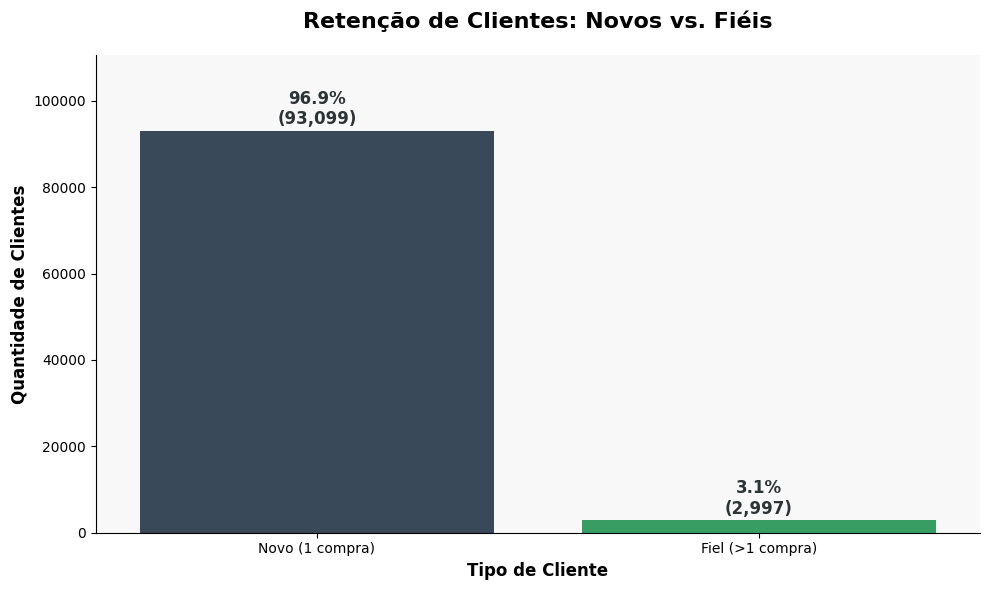

In [5]:
# 1. Distribuição de Clientes por Fidelidade
pedidos_por_cliente = df_consolidado.groupby('customer_unique_id')['order_id'].nunique().reset_index(name='qtd_pedidos')
pedidos_por_cliente['categoria'] = pedidos_por_cliente['qtd_pedidos'].apply(lambda x: 'Fiel (>1 compra)' if x > 1 else 'Novo (1 compra)')

plt.figure(figsize=(10, 6))
total = len(pedidos_por_cliente)
ax = sns.countplot(
    data=pedidos_por_cliente, 
    x='categoria', 
    palette={'Novo (1 compra)': '#34495e', 'Fiel (>1 compra)': '#27ae60'}, 
    order=['Novo (1 compra)', 'Fiel (>1 compra)']
)

plt.title('Retenção de Clientes: Novos vs. Fiéis', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tipo de Cliente', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de Clientes', fontsize=12, fontweight='bold')

# Adicionando % e valores absolutos nas barras
for p in ax.patches:
    pct = '{:.1f}%'.format(100 * p.get_height() / total)
    ax.annotate(f'{pct}\n({int(p.get_height()):,})', 
                (p.get_x() + p.get_width() / 2., p.get_height() + 500), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='#2d3436')

plt.ylim(0, total * 1.15)
sns.despine() # Remove as bordas superior e direita para um visual mais limpo
plt.tight_layout()
plt.show()


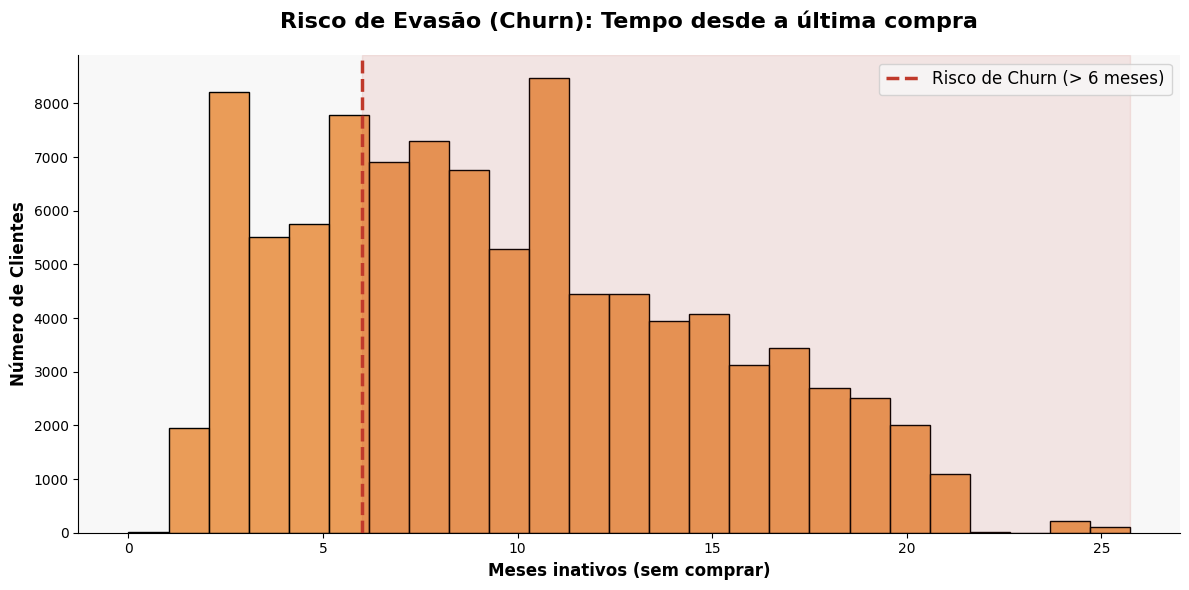

In [6]:
# 2. Análise de Inatividade (Risco de Churn)
# Qual o tempo médio desde a última compra?
ultima_compra = df_consolidado.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()
data_max = df_consolidado['order_purchase_timestamp'].max()
ultima_compra['meses_desde_compra'] = (data_max - ultima_compra['order_purchase_timestamp']).dt.days / 30

# Arredondando os meses e agrupando tudo acima de 10 como '10+'
ultima_compra['meses_inteiros'] = np.floor(ultima_compra['meses_desde_compra']).astype(int)
ultima_compra['meses_agrupados'] = ultima_compra['meses_inteiros'].apply(lambda x: f'{x}' if x < 10 else '10+')

# Contagem
contagem_meses = ultima_compra['meses_agrupados'].value_counts().reset_index()
contagem_meses.columns = ['meses_inativo', 'quantidade']

# Ordenar as categorias
ordem_categorias = [str(i) for i in range(10)] + ['10+']
contagem_meses['meses_inativo'] = pd.Categorical(contagem_meses['meses_inativo'], categories=ordem_categorias, ordered=True)
contagem_meses = contagem_meses.sort_values('meses_inativo')

plt.figure(figsize=(14, 7))
# Cores: Gradiente indicando aumento do risco (verdes suaves até vermelhos fortes)
paleta_cores = sns.blend_palette(['#27ae60', '#f1c40f', '#e67e22', '#c0392b'], n_colors=11)

ax = sns.barplot(
    data=contagem_meses, 
    x='meses_inativo', 
    y='quantidade', 
    palette=paleta_cores
)

# Adicionando uma linha de marcação após o 6º mês
plt.axvline(x=5.5, color='#c0392b', linestyle='--', linewidth=2, label='Início da inatividade crítica (> 6 meses)')

plt.title('Risco de Churn: Distribuição de Clientes por Meses Inativos', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Meses desde a Última Compra', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de Clientes', fontsize=12, fontweight='bold')

# Rótulos nas barras
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{int(altura):,}', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', fontsize=10, fontweight='bold', 
                    color='#2c3e50', xytext=(0, 5), textcoords='offset points')

plt.legend(fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()


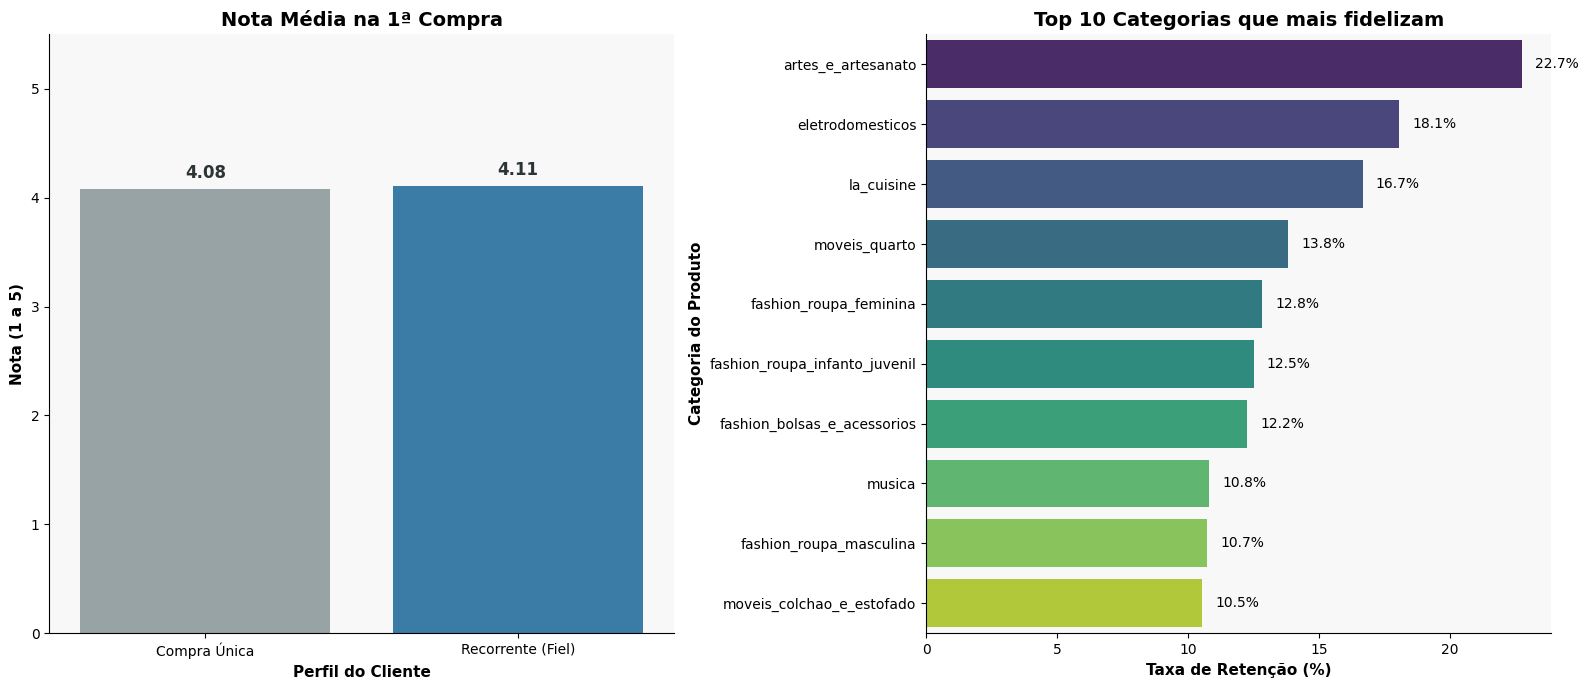

In [7]:
# 3. Fatores de Recompra: Avaliações e Categorias
df_primeira = df_consolidado.sort_values('order_purchase_timestamp').groupby('customer_unique_id').first().reset_index()
clientes_fieis = pedidos_por_cliente[pedidos_por_cliente['qtd_pedidos'] > 1]['customer_unique_id']
df_primeira['tipo_cliente'] = df_primeira['customer_unique_id'].apply(lambda x: 'Recorrente (Fiel)' if x in clientes_fieis.values else 'Compra Única')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
# Gráfico A: Gráfico de Barras com a Nota Média
satisfacao_media = df_primeira.groupby('tipo_cliente')['review_score'].mean().reset_index()
sns.barplot(
    data=satisfacao_media, x='tipo_cliente', y='review_score', ax=ax1, 
    palette={'Compra Única': '#95a5a6', 'Recorrente (Fiel)': '#2980b9'}
)
ax1.set_title('Nota Média na 1ª Compra', fontsize=14, fontweight='bold')
ax1.set_xlabel('Perfil do Cliente', fontsize=11, fontweight='bold')
ax1.set_ylabel('Nota (1 a 5)', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 5.5) # Limite fixo para representar a nota máxima
# Adicionando o rótulo de dados no topo de cada barra para facilitar a leitura
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=12, fontweight='bold', 
                 color='#2d3436', xytext=(0, 5), textcoords='offset points')
sns.despine(ax=ax1)
# Gráfico B: Categorias de Produtos com Maior Taxa de Retenção
df_cat = df_consolidado[df_consolidado['product_category_name'] != 'sem_categoria']
df_cat['fiel'] = df_cat['customer_unique_id'].isin(clientes_fieis)
top_cats = df_cat.groupby('product_category_name')['fiel'].mean().sort_values(ascending=False).head(10) * 100
sns.barplot(x=top_cats.values, y=top_cats.index, ax=ax2, palette='viridis')
ax2.set_title('Top 10 Categorias que mais fidelizam', fontsize=14, fontweight='bold')
ax2.set_xlabel('Taxa de Retenção (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Categoria do Produto', fontsize=11, fontweight='bold')
for i, v in enumerate(top_cats.values):
    ax2.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
sns.despine(ax=ax2)
plt.tight_layout()
plt.show()

## **7. Sugestões de Melhoria**

Para um retorno efetivo, propomos trabalhar em **duas frentes** (curto e longo prazo):

1.  **Programa de Pontos**: Criar sistema de recompensa para converter a 2ª compra.
2.  **Lembrete de 'Sumiço'**: Automação para clientes inativos há mais de 4 meses.
3.  **Cuidado com Atrasos**: Cupom de desculpas imediato para problemas de entrega.
4.  **Sugestões do seu Jeito**: Cross-selling baseando na primeira compra.
5.  **Ajuste da Operação (Problema Raiz)**: Negociar novos contratos com transportadoras. Como a logística não acompanhou as vendas, essa parte leva mais tempo (meses de trabalho), mas é a solução real a longo prazo.